# tcode 计算器

从 Excel 导入发光时序，按**全局参数字典**搜索能滤净模组内鬼影/串扰的 `tx_trig_dly` 码表。

**验收标准（不可妥协）**：1~600m 距离扫描下，XM 之后**鬼影残留 = 0 且真峰误杀 = 0**。
只有满足这一条的码表才算数；**时间压缩只在零残留的解里进行**，
带残留的更短码表一律不采纳。

当前已知零残留最短预算（gap=2, SEP=12）：`XM.ratio=1.5` → **32ns**；`2.5` → **24ns**。
搜索策略：`fast_search_v22` 码差抽样狂产可行解 + 短重启兜底（不用 min-conflicts 长跑）。

| 步骤 | 内容 |
|---|---|
| 1 | 读 Excel 时序，画 kick 栅格（配色同 v30 图 V30-1） |
| 2 | 全局参数字典：`SCENE` / `TIMING` / `XM` / `TCODE` / `SEARCH` |
| 3 | 阶段 A 先拿零残留（已知表优先，默认 32ns）；阶段 B 再逐档下压 |
| 4 | 打印条件 + 压缩过程 + tcode 码矩阵 / 发光栅格；若有残留，列出鬼影位置 |

缩写：XM（XtalkMark，串扰标记）、TOF（Time of Flight，飞行时间）、
SEP（Separation，峰可分辨最小间隔）。


In [1]:
# ============================================================================
# 0. 导入
# ============================================================================
import os, sys, time, copy
from collections import defaultdict
from itertools import combinations

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import openpyxl
from matplotlib.patches import Rectangle

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    try:
        matplotlib.use("module://matplotlib_inline.backend_inline")
    except Exception:
        pass

for _f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    try:
        plt.rcParams["font.sans-serif"] = [_f]
        break
    except Exception:
        continue
plt.rcParams["axes.unicode_minus"] = False

def show_fig(fig=None):
    """兼容 notebook / nbclient：优先 inline display。"""
    fig = fig or plt.gcf()
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        pass
    plt.close(fig)


C_LIGHT = 2.99792458e8
NS = 1e-9
KICK_SPACING = 2.2e-6
TOF_WINDOW = 2000e-9
N_BINS = 2000

# 把 docs/tcode 放进路径，复用已验证求解器
sys.path.insert(0, os.path.join("docs", "tcode"))


In [2]:
# ============================================================================
# 1. 从 Excel 导入发光时序
# ============================================================================
EXCEL_FILE = "Elephant 时序表.xlsx"
wb = openpyxl.load_workbook(EXCEL_FILE, data_only=True)
ws = wb["长焦"]
COL_A = range(8, 24)

tdelay_A = {}
for c in COL_A:
    v = ws.cell(4, c).value
    tdelay_A[c - 8] = int(v) if v is not None else 0

laser_fires_raw = []
laser_ids = []
for r in range(7, 106):
    v = ws.cell(r, 6).value
    if v is None:
        continue
    try:
        lid = int(v)
    except (ValueError, TypeError):
        continue
    laser_ids.append(lid)
    for k, c in enumerate(COL_A):
        x = ws.cell(r, c).value
        if x is not None:
            laser_fires_raw.append((lid, k, int(x)))

laser_ids = sorted(set(laser_ids))
N_LASERS = len(laser_ids)
SHOT_KICKS = {lid: sorted(k for (l, k, tx) in laser_fires_raw if l == lid)
              for lid in laser_ids}
EXCEL_TX = {(l, k): tx for (l, k, tx) in laser_fires_raw}
N_ACC = int(np.median([len(v) for v in SHOT_KICKS.values()]))

def laser_color(laser_id):
    # 与 crosstalk_sim_v30 图 V30-1 完全一致：HSV 按激光器编号均匀取色
    idx = (laser_id - 1) % max(N_LASERS, 1)
    return mcolors.hsv_to_rgb((idx / max(N_LASERS, 1), 0.65, 0.92))

print(f"1. 已读 {EXCEL_FILE} [长焦]：{N_LASERS} 激光器，"
      f"每激光器约 {N_ACC} 次 kick，共 {len(laser_fires_raw)} 次发光")
for lid in laser_ids:
    print(f"  L{lid:>2d}: kicks={SHOT_KICKS[lid]}")


1. 已读 Elephant 时序表.xlsx [长焦]：16 激光器，每激光器约 4 次 kick，共 64 次发光
  L 1: kicks=[7, 8, 9, 15]
  L 2: kicks=[11, 12, 13, 14]
  L 3: kicks=[7, 8, 9, 15]
  L 4: kicks=[11, 12, 13, 14]
  L 5: kicks=[0, 1, 2, 6]
  L 6: kicks=[3, 4, 5, 10]
  L 7: kicks=[0, 1, 2, 6]
  L 8: kicks=[3, 4, 5, 10]
  L 9: kicks=[0, 1, 2, 6]
  L10: kicks=[3, 4, 5, 10]
  L11: kicks=[0, 1, 2, 6]
  L12: kicks=[3, 4, 5, 10]
  L13: kicks=[7, 8, 9, 15]
  L14: kicks=[11, 12, 13, 14]
  L15: kicks=[7, 8, 9, 15]
  L16: kicks=[11, 12, 13, 14]


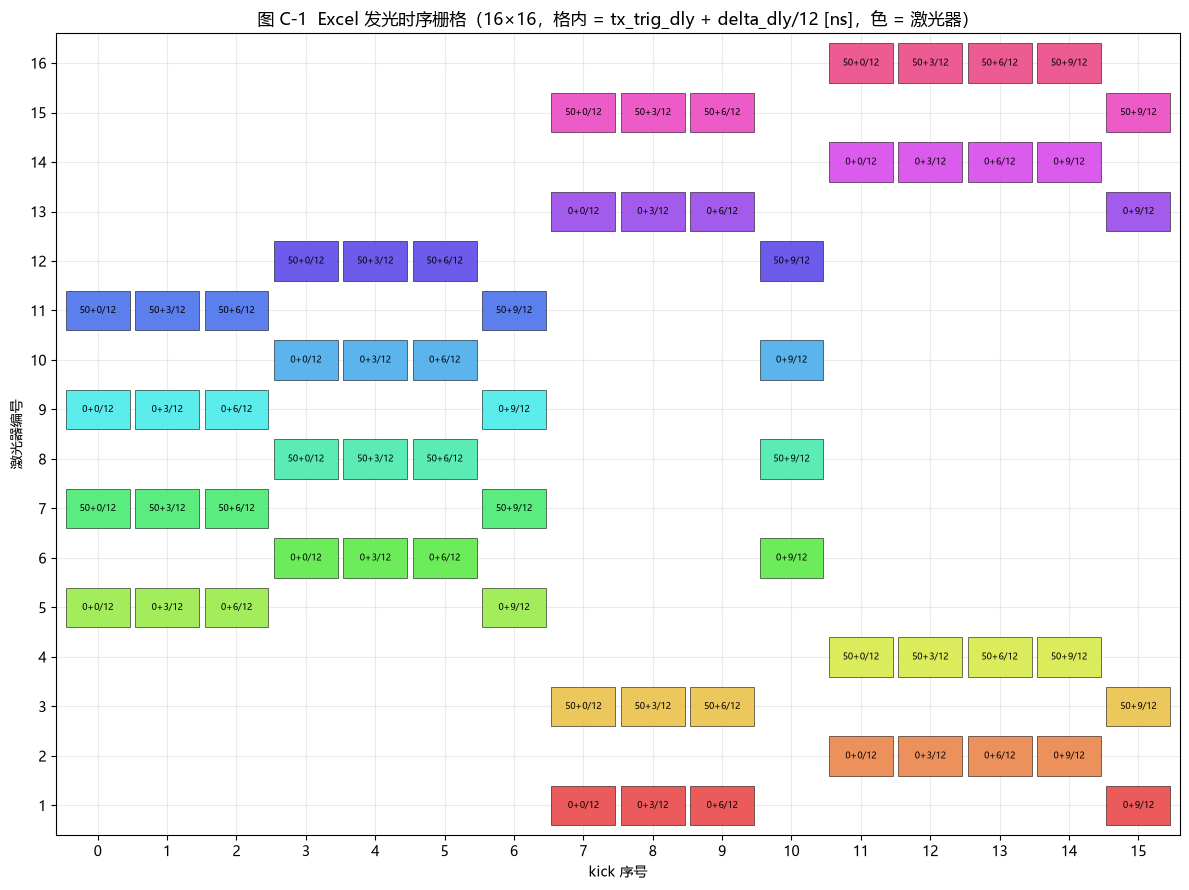

1b. delta_dly（Excel 第4行 tdelay，1/12 ns 步长，按 kick）：
  kick :   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15
  delta:   0   3   6   0   3   6   9   0   3   6   9   0   3   6   9   9


In [3]:
# ============================================================================
# 1b. 发光时序 kick 栅格（与 v30 图 V30-1 同风格 / 同配色）
# ============================================================================
# 格内 = tx_trig_dly + delta_dly/12，单位 ns。
#   tx_trig_dly : 1 ns 步长（Excel 各 kick 的发光延时）
#   delta_dly   : 1/12 ns 步长（Excel 第 4 行 tdelay，按 kick 给出，与激光器无关）
def plot_kick_grid(label_of, title):
    fig, ax = plt.subplots(figsize=(12, 9))
    for lid in laser_ids:
        for k in SHOT_KICKS[lid]:
            ax.add_patch(plt.Rectangle(
                (k - 0.46, lid - 0.40), 0.92, 0.80,
                facecolor=laser_color(lid), edgecolor="k",
                linewidth=0.4, alpha=0.95, zorder=2))
            ax.text(k, lid, f"{label_of(lid, k)}", fontsize=6.5,
                    ha="center", va="center", color="k", zorder=3)
    ax.set_xticks(range(16)); ax.set_yticks(laser_ids)
    ax.set_xlim(-0.6, 15.6); ax.set_ylim(0.4, N_LASERS + 0.6)
    ax.set_xlabel("kick 序号")
    ax.set_ylabel("激光器编号")
    ax.set_title(title)
    ax.grid(alpha=0.25, zorder=0); ax.set_axisbelow(True)
    plt.tight_layout(); show_fig(fig)


def code_label(tx_ns, kick):
    return f"{tx_ns}+{tdelay_A.get(kick, 0)}/12"


plot_kick_grid(lambda lid, k: code_label(EXCEL_TX[(lid, k)], k),
               f"图 C-1  Excel 发光时序栅格（{N_LASERS}×16，"
               f"格内 = tx_trig_dly + delta_dly/12 [ns]，色 = 激光器）")

print("1b. delta_dly（Excel 第4行 tdelay，1/12 ns 步长，按 kick）：")
print("  kick : " + " ".join(f"{k:>3d}" for k in range(16)))
print("  delta: " + " ".join(f"{tdelay_A[k]:>3d}" for k in range(16)))


In [4]:
# ============================================================================
# 2. 全局参数字典（风格对齐 crosstalk_sim_v30）
# ============================================================================
# ---- 场景 / 输入 ----
SCENE = {
    "excel_file": EXCEL_FILE,
    "sheet": "长焦",
}

# ---- 发光时序编码（本工具只读 Excel；求解输出的是 tx_trig_dly）----
TIMING = {
    "use_tx_trig_dly": True,   # 1 ns 步长
    "use_delta_dly": False,    # 1/12 ns；求解不写入 delta，仅栅格展示
}

# ---- XM（XtalkMark，串扰标记）----
XM = {
    "ratio": 1.5,              # hist_max × ratio > hist_add → 丢掉
    "use_pulse_width": False,  # False = 验收用理想 δ 回波
    "pulse_width_ns": 8.0,     # 假设脉宽（SEP 通常 = 脉宽 + 裕度）
    "require_zero_residual": True,  # 验收硬指标：鬼影残留=0 且真峰误杀=0
}

# ---- tcode 约束 ----
TCODE = {
    "consider_gap": True,      # True：编号间隔 > max_gap 的串扰忽略
    "max_gap": 2,              # 可忽略阈值
    "sep_ns": 12,              # 散开 + 避真最小间隔 [ns]
}

# ---- 搜索：先滤净，再压预算 ----
# 策略（已验证）：码差抽样(fast_search_v22)狂产可行解 → 粗筛零残留 → 细扫验收
# min-conflicts 只用「短重启」(steps≈5000)，不用长跑（重尾坏情况极慢）
SEARCH = {
    "budget_hint_ns": None,     # None=按 XM.ratio / gap 自动取已知滤净起点
    "budget_max_ns": 128,       # 阶段 A 上探上限
    "budget_step_ns": 4,        # 阶段 B 每次下压步长
    "seconds_per_budget": 120.0,# 每档预算时限 [s]；36ns 零残留通常几十秒内出
    "max_misses": 2,            # 阶段 B 连续几档搜不到零残留就停
    "short_steps": 5000,        # 短重启最大步数
    "short_plateau": 800,       # 短重启 plateau
    "seed": 2026,
    "eval_step_m": 5.0,         # 验收距离扫描步长 [m]
    "screen_step_m": 10.0,      # 粗筛步长（先粗后细）
    "diag_step_m": 10.0,
    "diag_max_show": 40,
}

# 已知「零残留」最短预算（gap=2, SEP=12, 本 Excel）：
#   约束硬下界 2×SEP=24ns；ratio=2.5 → 24ns；ratio=1.5 → 32ns（已确认；36ns 是更宽备用）
def auto_budget_hint():
    if SEARCH["budget_hint_ns"] is not None:
        return int(SEARCH["budget_hint_ns"])
    if not TCODE["consider_gap"] or TCODE["max_gap"] < 2:
        return 72
    r = float(XM["ratio"])
    if r >= 2.5:
        return 24
    if r >= 1.5:
        return 32
    return 80

def hard_lower_bound():
    """同组共发激光两两错开 SEP 所需的最小预算。"""
    sep = int(TCODE["sep_ns"])
    return 2 * sep if (TCODE["consider_gap"] and TCODE["max_gap"] <= 2) else 3 * sep

print("2. 全局参数")
for name, d in [("SCENE", SCENE), ("TIMING", TIMING), ("XM", XM),
                ("TCODE", TCODE), ("SEARCH", SEARCH)]:
    print("  " + name + ": {")
    for k, v in d.items():
        print(f"    {k}: {v}")
    print("  }")
print(f"  → 验收硬指标: 1~600m 扫描鬼影残留=0 且真峰误杀=0")
print(f"  → 预算起点 {auto_budget_hint()} ns，硬下界 {hard_lower_bound()} ns")


2. 全局参数
  SCENE: {
    excel_file: Elephant 时序表.xlsx
    sheet: 长焦
  }
  TIMING: {
    use_tx_trig_dly: True
    use_delta_dly: False
  }
  XM: {
    ratio: 1.5
    use_pulse_width: False
    pulse_width_ns: 8.0
    require_zero_residual: True
  }
  TCODE: {
    consider_gap: True
    max_gap: 2
    sep_ns: 12
  }
  SEARCH: {
    budget_hint_ns: None
    budget_max_ns: 128
    budget_step_ns: 4
    seconds_per_budget: 120.0
    max_misses: 2
    short_steps: 5000
    short_plateau: 800
    seed: 2026
    eval_step_m: 5.0
    screen_step_m: 10.0
    diag_step_m: 10.0
    diag_max_show: 40
  }
  → 验收硬指标: 1~600m 扫描鬼影残留=0 且真峰误杀=0
  → 预算起点 32 ns，硬下界 24 ns


In [5]:
# ============================================================================
# 3. 核心：约束构建 / min-conflicts / 验收 / 残留定位
# ============================================================================
import solve_tcode as S
import gen_tcode_figures as G
import fast_search_v22 as F

# 用本 notebook 的 Excel 时序覆盖 gen_tcode_figures / solve_tcode 全局表
G.LASER_IDS = list(laser_ids)
G.KICKS_OF = {l: list(SHOT_KICKS[l]) for l in laser_ids}
G.N_ACC = N_ACC
G.TX_EXCEL = dict(EXCEL_TX)
G.FIRES_RAW = list(laser_fires_raw)

S.LASER_IDS = list(laser_ids)
S.KICKS_OF = {l: list(SHOT_KICKS[l]) for l in laser_ids}
S.N_ACC = N_ACC
S.VARS = [(l, k) for l in laser_ids for k in SHOT_KICKS[l]]
S.VIDX = {v: i for i, v in enumerate(S.VARS)}

F.LASER_IDS = list(laser_ids)
F.KICKS_OF = {l: tuple(SHOT_KICKS[l]) for l in laser_ids}
F.VIDX = S.VIDX


def rebuild_constraints(gap, sep):
    """按 TCODE 参数重建散开类 / 避真对。"""
    S.CROSSTALK_MAX_GAP = gap
    S.set_sep(sep)
    S.CLASSES = S.build_classes(gap=gap)
    S.AVOID_PAIRS = S.build_avoid_true(gap=gap)
    S.VAR2CLS = [[] for _ in S.VARS]
    for ci, (_, prs) in enumerate(S.CLASSES):
        for ia, ib in prs:
            S.VAR2CLS[ia].append(ci)
            S.VAR2CLS[ib].append(ci)
    S.VAR2CLS = [sorted(set(c)) for c in S.VAR2CLS]
    S.VAR2AVOID = [[] for _ in S.VARS]
    for pi, (ia, ib) in enumerate(S.AVOID_PAIRS):
        S.VAR2AVOID[ia].append(pi)
        S.VAR2AVOID[ib].append(pi)
    return len(S.CLASSES), len(S.AVOID_PAIRS)


def known_table_candidates():
    """已核验「零残留」码表（gap=2 / SEP=12 / 本 Excel），按预算从小到大。

    ratio=1.5 最短零残留 = 32ns（tcode_table_zero_r1.5_32ns.py）；
    36/40/56ns 只是更宽的备用表，不是起点。
    """
    if not (TCODE["consider_gap"] and TCODE["max_gap"] == 2 and TCODE["sep_ns"] == 12):
        return []
    r = float(XM["ratio"])
    if r >= 2.5:
        names = ["tcode_table_v22_r2.5_24ns.py",
                 "tcode_table_zero_r2.5_24ns.py",
                 "tcode_table_zero_r1.5_32ns.py"]
    elif r >= 1.5:
        names = ["tcode_table_zero_r1.5_32ns.py",
                 "tcode_table_zero_r1.5_36ns.py",
                 "tcode_table_zero_r1.5_40ns.py",
                 "tcode_table_v22_r1.5_56ns.py",
                 "tcode_table_v22_80ns_zero.py"]
    else:
        names = ["tcode_table_v22_80ns_zero.py"]
    out = []
    for n in names:
        path = os.path.join("docs", "tcode", n)
        if not os.path.isfile(path):
            continue
        ns = {}
        with open(path, encoding="utf-8") as f:
            exec(compile(f.read(), path, "exec"), ns)
        tbl = ns["TCODE_TABLE"]
        if any((l, k) not in tbl for l, k in S.VARS):
            continue
        u = np.array([tbl[(l, k)] for (l, k) in S.VARS], dtype=np.int32)
        out.append((u, path))
    return out


def is_zero(u, ratio, gap):
    """两级验收：先粗筛，再细扫；返回 (是否零残留, 细扫统计)。"""
    ev = evaluate_code(u, ratio, SEARCH["screen_step_m"], gap)
    if ev["ga"] or ev["kill"]:
        return False, ev
    ev = evaluate_code(u, ratio, SEARCH["eval_step_m"], gap)
    return (ev["ga"] == 0 and ev["kill"] == 0), ev


def search_zero(budget, ratio, gap, sep, seconds, seed):
    """在预算内找「零残留」码表（与 docs/tcode/_zero_batch.py 同策略）。

    主通道：fast_search_v22 码差抽样（紧预算秒级出可行解）
    兜底：min-conflicts 短重启（steps/plateau 取 SEARCH 配置；禁止长跑）
    每个可行解立刻粗筛→细扫验收。
    """
    groups = F.laser_groups()
    quads = F.valid_quads(budget, sep)
    rng = np.random.default_rng(seed)
    t0 = time.time()
    n_feas = n_try = 0
    best_ga = None
    short_steps = int(SEARCH.get("short_steps", 5000))
    short_plateau = int(SEARCH.get("short_plateau", 800))

    while time.time() - t0 < seconds:
        n_try += 1
        u = None
        # ---- 主通道：码差抽样 ----
        if quads:
            codes, ok = {}, True
            for ks, ls in groups:
                sol = None
                for _ in range(80):
                    sol = F.try_group(budget, sep, ks, ls, quads, rng)
                    if sol is not None:
                        break
                if sol is None:
                    ok = False
                    break
                codes.update(sol)
            if ok:
                u = np.zeros(len(S.VARS), dtype=np.int32)
                for (l, k), vi in S.VIDX.items():
                    u[vi] = codes[(l, k)]
                if S.total_cost(u) != 0:
                    u = None
        # ---- 兜底：短重启（每 20 次抽样尝试一次，避免拖慢主通道）----
        if u is None and (n_try % 20 == 0) and time.time() - t0 < seconds:
            u = S.solve(budget, rng, max_steps=short_steps, plateau=short_plateau)
        if u is None:
            continue
        n_feas += 1
        ok, ev = is_zero(u, ratio, gap)
        if ok:
            return u, {"feasible": n_feas, "tries": n_try, "eval": ev,
                       "secs": time.time() - t0, "best_ga": 0}
        if best_ga is None or ev["ga"] < best_ga:
            best_ga = ev["ga"]
        if n_feas % 50 == 0:
            print(f"    … 可行{n_feas}/{n_try} 最好残留={best_ga} "
                  f"[{time.time()-t0:.0f}s]", flush=True)
    return None, {"feasible": n_feas, "tries": n_try, "best_ga": best_ga,
                  "secs": time.time() - t0}


def evaluate_code(u, ratio, step_m, gap):
    fn = S.make_code_fn(u)
    # evaluate 内部用 G.simulate，需把 max_gap 传进去 —— 包装一层
    fr = G.build_firings(fn)
    tot = dict(gb=0, ga=0, tb=0, kill=0, res_same=0, res_cross=0, res_mix=0)
    for D in np.arange(5.0, 601.0, step_m):
        r = G.simulate(D, fr, max_gap=gap, ratio=ratio)
        for k in tot:
            tot[k] += r[k]
    return tot


def diagnose_residuals(u, ratio, gap, step_m, max_show):
    """列出残留鬼影峰位置：距离 D、接收激光、bin/等效距离、成因、shot 命中。"""
    fn = S.make_code_fn(u)
    fr = G.build_firings(fn)
    rows = []
    for D in np.arange(5.0, 601.0, step_m):
        tof = 2.0 * D / C_LIGHT
        shot_idx = {l: {k: i for i, k in enumerate(SHOT_KICKS[l])} for l in laser_ids}
        H = {l: np.zeros((len(SHOT_KICKS[l]), N_BINS)) for l in laser_ids}
        truth = {l: np.zeros(N_BINS, dtype=bool) for l in laser_ids}
        src = {l: [[] for _ in range(N_BINS)] for l in laser_ids}

        for (ea, ek, et) in fr:
            t_echo = et + tof
            for (ra, rk, rt) in fr:
                if not (rt <= t_echo <= rt + TOF_WINDOW):
                    continue
                is_true = (ea == ra and ek == rk)
                if (not is_true) and abs(ea - ra) > gap:
                    continue
                b = int(np.clip(np.floor((t_echo - rt) / NS), 0, N_BINS - 1))
                H[ra][shot_idx[ra][rk], b] += 1.0
                if is_true:
                    truth[ra][b] = True
                else:
                    src[ra][b].append((ea, ek, rk, ea == ra))

        for l in laser_ids:
            add, mx = H[l].sum(axis=0), H[l].max(axis=0)
            for b in np.flatnonzero(add > 0.5):
                if truth[l][b]:
                    continue
                if mx[b] * ratio > add[b]:
                    continue  # 已被 XM 丢掉
                # 残留
                kinds = src[l][b]
                same = any(ek == rk for _, ek, rk, _ in kinds)
                cross = any(ek != rk for _, ek, rk, _ in kinds)
                self_al = any(is_self for *_, is_self in kinds)
                if same and cross:
                    kind = "混合(同kick+跨kick)"
                elif same:
                    kind = "同kick串扰"
                elif self_al:
                    kind = "自身混叠"
                else:
                    kind = "跨kick串扰"
                dist_m = b * NS * C_LIGHT / 2.0
                rows.append({
                    "D_m": D, "recv": l, "bin": int(b), "dist_m": dist_m,
                    "tof_ns": b, "add": float(add[b]), "max": float(mx[b]),
                    "ratio_eff": float(add[b] / max(mx[b], 1e-9)),
                    "kind": kind,
                    "sources": kinds[:8],
                })
                if len(rows) >= max_show:
                    return rows
    return rows


def plot_tcode_matrix(table, budget, title):
    fig, ax = plt.subplots(figsize=(12, 7))
    mat = np.full((N_LASERS, 16), np.nan)
    for i, lid in enumerate(laser_ids):
        for k in SHOT_KICKS[lid]:
            mat[i, k] = table[(lid, k)]
    vmax = max(budget, 1)
    im = ax.imshow(mat, origin="lower", aspect="auto", cmap="viridis",
                   extent=[-0.5, 15.5, 0.5, N_LASERS + 0.5],
                   vmin=0, vmax=vmax)
    for i, lid in enumerate(laser_ids):
        for k in SHOT_KICKS[lid]:
            v = table[(lid, k)]
            ax.text(k, lid, str(v), ha="center", va="center", fontsize=7,
                    color="white" if v < vmax * 0.55 else "black")
    ax.set_xticks(range(16)); ax.set_yticks(laser_ids)
    ax.set_xlabel("kick"); ax.set_ylabel("激光器")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="tx_trig_dly [ns]")
    plt.tight_layout(); show_fig(fig)


print("3. 核心函数就绪（rebuild / search / evaluate / diagnose / plot）")


  已读取 Excel 时序：16 激光器 / 64 次发光
3. 核心函数就绪（rebuild / search / evaluate / diagnose / plot）


In [6]:
# ============================================================================
# 4. 计算 tcode —— 先滤净，再压预算
#    阶段 A：拿到一张「零残留」码表（已知表优先，不行就向上搜）
#    阶段 B：在零残留前提下逐档下压预算；带残留的更短码表一律不收
# ============================================================================
gap = TCODE["max_gap"] if TCODE["consider_gap"] else 15
sep = int(TCODE["sep_ns"])
ratio = float(XM["ratio"])
hint = auto_budget_hint()
lb = hard_lower_bound()

n_cls, n_av = rebuild_constraints(gap, sep)
F.GAP = gap
print("=" * 72)
print("约束规模")
print(f"  consider_gap={TCODE['consider_gap']}  max_gap={gap}  SEP={sep}ns")
print(f"  散开鬼影类={n_cls}  避真对数={n_av}  变量数={len(S.VARS)}")
print(f"  XM_RATIO={ratio}  验收=鬼影残留0 且 真峰误杀0（1~600m 步长 "
      f"{SEARCH['eval_step_m']}m）")
print(f"  预算起点={hint}ns（ratio=1.5 已知零残留最短=32ns）")
print(f"  上探上限={SEARCH['budget_max_ns']}ns  硬下界={lb}ns")
print(f"  搜法=码差抽样(fast_search) + 短重启(steps={SEARCH['short_steps']})")
print("=" * 72)

RESULT = {
    "ok": False, "u": None, "table": None, "budget": None,
    "source": None, "eval": None, "residuals": [], "trace": [],
}


def take(u, tag, ev):
    RESULT.update(u=u.copy(), budget=int(u.max()), source=tag, eval=ev, ok=True)


# ---- 阶段 A：先拿到零残留解 ----
print("\n阶段 A · 先滤净")
for u_k, path in known_table_candidates():
    if S.total_cost(u_k) != 0:
        continue
    ok, ev = is_zero(u_k, ratio, gap)
    mark = "★零残留" if ok else f"残留 {ev['ga']}"
    print(f"  已知表 {os.path.basename(path):<34} max={int(u_k.max()):>3d}ns  {mark}")
    if ok:
        take(u_k, f"known:{os.path.basename(path)}", ev)
        break

if not RESULT["ok"]:
    B = max(hint, lb)
    while B <= SEARCH["budget_max_ns"]:
        u, info = search_zero(B, ratio, gap, sep,
                              SEARCH["seconds_per_budget"], SEARCH["seed"] + B)
        if u is not None:
            print(f"  搜索 B={B:>3d}ns ★零残留（可行 {info['feasible']}/"
                  f"{info.get('tries','?')}，{info['secs']:.0f}s）")
            take(u, f"search:B={B}", info["eval"])
            break
        print(f"  搜索 B={B:>3d}ns 失败（可行 {info['feasible']}/"
              f"{info.get('tries','?')}，最好残留 {info['best_ga']}，"
              f"{info['secs']:.0f}s）")
        B += SEARCH["budget_step_ns"]

# ---- 阶段 B：零残留前提下压预算 ----
if RESULT["ok"]:
    print(f"\n阶段 B · 从 {RESULT['budget']}ns 起下压（步长 "
          f"{SEARCH['budget_step_ns']}ns，硬下界 {lb}ns；"
          f"每档最多 {SEARCH['seconds_per_budget']:.0f}s）")
    misses = 0
    B = RESULT["budget"] - SEARCH["budget_step_ns"]
    while B >= lb and misses <= SEARCH["max_misses"]:
        u, info = search_zero(B, ratio, gap, sep,
                              SEARCH["seconds_per_budget"], SEARCH["seed"] + B)
        if u is not None:
            print(f"  B={B:>3d}ns ★零残留 → 采纳（可行 {info['feasible']}/"
                  f"{info.get('tries','?')}，{info['secs']:.0f}s）")
            take(u, f"compress:B={B}", info["eval"])
            RESULT["trace"].append((B, True))
            misses = 0
        else:
            print(f"  B={B:>3d}ns 压不动（可行 {info['feasible']}/"
                  f"{info.get('tries','?')}，最好残留 {info['best_ga']}，"
                  f"{info['secs']:.0f}s）")
            RESULT["trace"].append((B, False))
            misses += 1
        B -= SEARCH["budget_step_ns"]
    if RESULT["budget"] <= lb:
        print(f"  已达硬下界 {lb}ns，不能再压")

# ---- 结果 / 残留定位 ----
if RESULT["u"] is not None:
    RESULT["table"] = {(l, k): int(RESULT["u"][S.VIDX[(l, k)]])
                       for (l, k) in S.VARS}
    if not RESULT["ok"]:
        print("\n未滤净：定位残留鬼影位置 ...")
        RESULT["residuals"] = diagnose_residuals(
            RESULT["u"], ratio, gap, SEARCH["diag_step_m"], SEARCH["diag_max_show"])
else:
    print("\n★ 预算上限内没找到零残留码表：可提高 SEARCH.budget_max_ns / "
          "seconds_per_budget，或放宽 XM.ratio。")

TCODE_TABLE = RESULT["table"]
TCODE_OK = RESULT["ok"]
print("\n结果:", "滤净成功" if TCODE_OK else "未完全滤净 / 无解",
      f"| source={RESULT['source']} | 最短零残留预算={RESULT['budget']}ns")


约束规模
  consider_gap=True  max_gap=2  SEP=12ns
  散开鬼影类=56  避真对数=40  变量数=64
  XM_RATIO=1.5  验收=鬼影残留0 且 真峰误杀0（1~600m 步长 5.0m）
  预算起点=32ns（ratio=1.5 已知零残留最短=32ns）
  上探上限=128ns  硬下界=24ns
  搜法=码差抽样(fast_search) + 短重启(steps=5000)

阶段 A · 先滤净


  已知表 tcode_table_zero_r1.5_32ns.py      max= 32ns  ★零残留

阶段 B · 从 32ns 起下压（步长 4ns，硬下界 24ns；每档最多 120s）


  B= 28ns 压不动（可行 1/1840，最好残留 381，121s）


  B= 24ns 压不动（可行 37/1520，最好残留 594，121s）

结果: 滤净成功 | source=known:tcode_table_zero_r1.5_32ns.py | 最短零残留预算=32ns


tcode 计算器 · 条件与结果

【输入】
  Excel 文件          : Elephant 时序表.xlsx
  激光器数            : 16
  每激光器 kick 数    : 4
  发光事件总数        : 64

【TIMING】
  use_tx_trig_dly     : True
  use_delta_dly       : False（本工具求解只输出 tx_trig_dly）

【串扰 / TCODE】
  编号间隔可忽略      : consider_gap = True
  可忽略阈值          : 激光编号差 > 2 则不考虑串扰
  码间隔 SEP          : 12 ns（散开 + 避真）

【XM】
  xm_ratio            : 1.5
  use_pulse_width     : False（False=理想 δ）
  假设脉宽            : 8.0 ns
  滤净要求            : require_zero_residual = True

【求解】先滤净，再压预算
  来源                : known:tcode_table_zero_r1.5_32ns.py
  最短零残留预算      : 32 ns（= max(tx_trig_dly)）
  约束：散开鬼影类    : 56
  约束：避真对数      : 40

【验收】距离扫描 5~600m，步长 5.0m，XM_RATIO=1.5
  鬼影峰  10139 → 残留 0  (0.000%)
  真峰    944，误杀 0
  残留分类: 同kick=0  跨kick=0  混合=0
  ★ 结论：在当前条件下，鬼影/串扰可被全部滤除，真峰无误杀。

【压缩过程】只有零残留的更短码表才被采纳
   28 ns : 有残留/无可行解 → 放弃
   24 ns : 有残留/无可行解 → 放弃
  最终 32 ns

【tcode 码表】tx_trig_dly [ns]
  L1   K7=0  K8=24  K9=31  K15=10
  L2   K11=2  K12=22  K13=28  K14=8
  L3   K7=31  K8=8  K

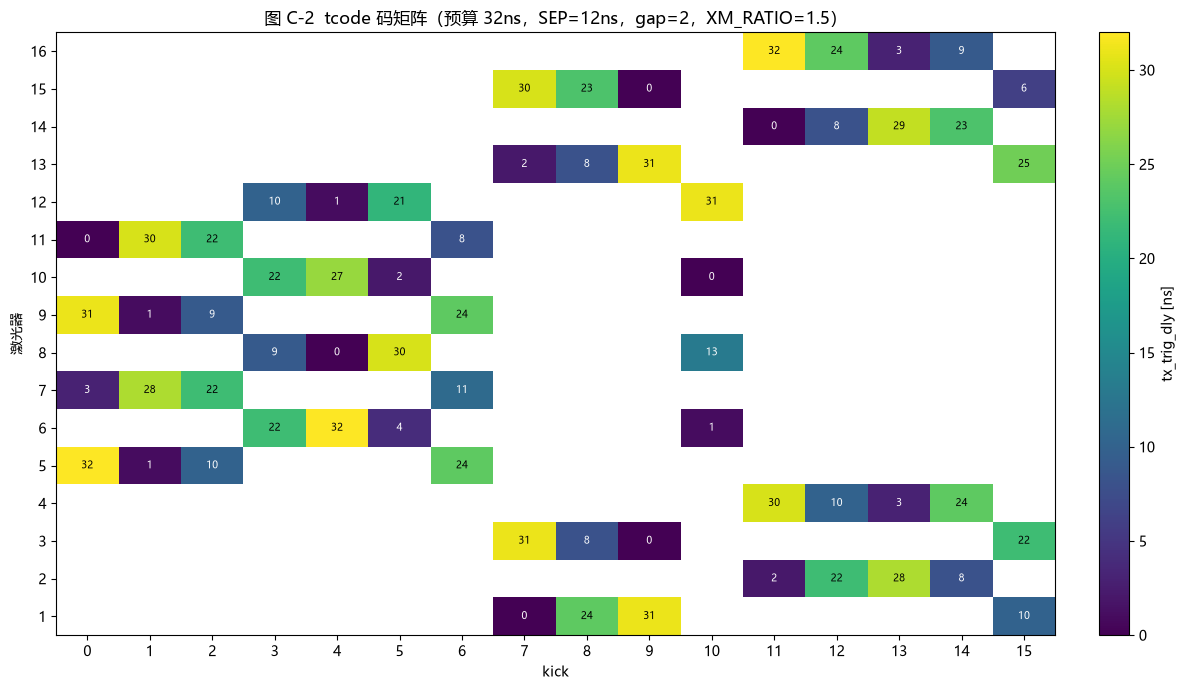

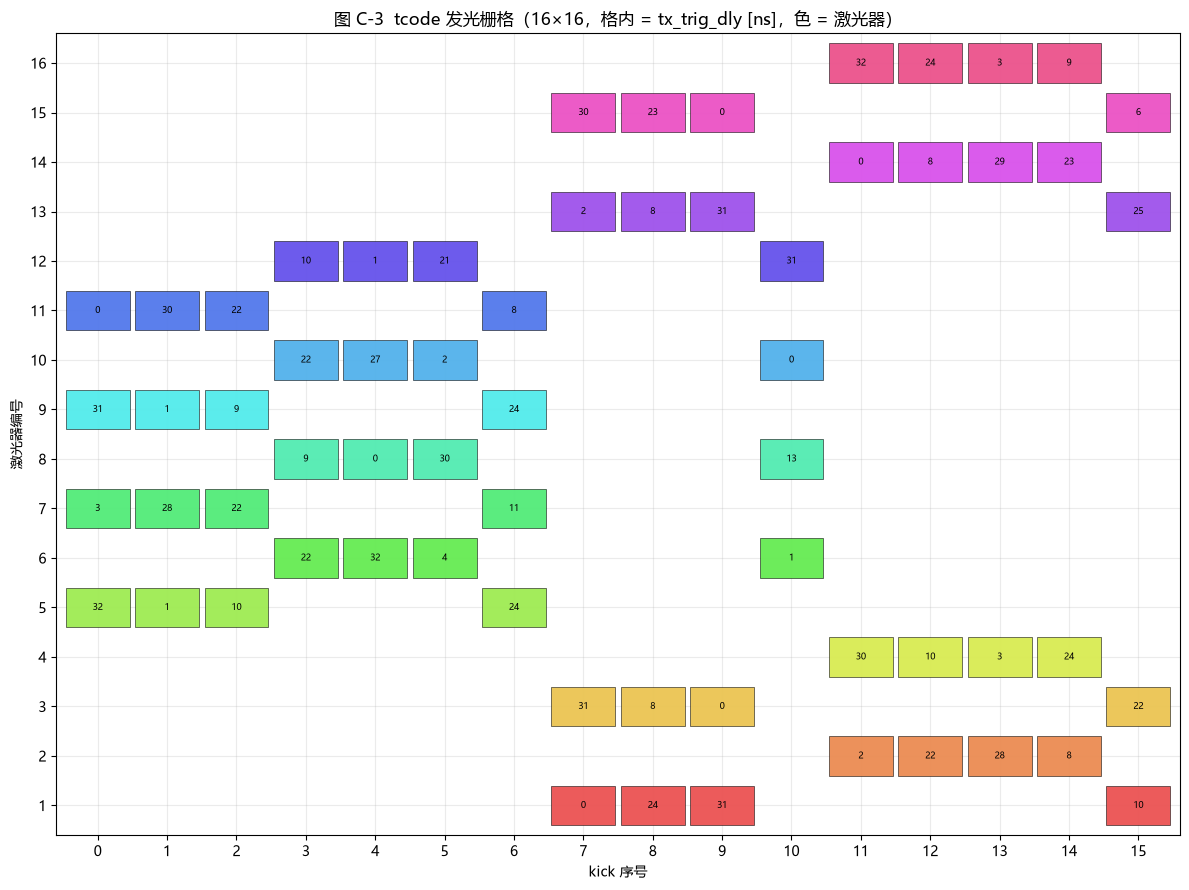


无残留鬼影。


In [7]:
# ============================================================================
# 5. 打印条件 + 码图 + 残留说明
# ============================================================================
print("=" * 72)
print("tcode 计算器 · 条件与结果")
print("=" * 72)

print("""
【输入】
  Excel 文件          : {excel}
  激光器数            : {n_lasers}
  每激光器 kick 数    : {n_acc}
  发光事件总数        : {n_fire}

【TIMING】
  use_tx_trig_dly     : {tx}
  use_delta_dly       : {dd}（本工具求解只输出 tx_trig_dly）

【串扰 / TCODE】
  编号间隔可忽略      : consider_gap = {cg}
  可忽略阈值          : 激光编号差 > {gap} 则不考虑串扰
  码间隔 SEP          : {sep} ns（散开 + 避真）

【XM】
  xm_ratio            : {ratio}
  use_pulse_width     : {upw}（False=理想 δ）
  假设脉宽            : {pw} ns
  滤净要求            : require_zero_residual = {rz}

【求解】先滤净，再压预算
  来源                : {src}
  最短零残留预算      : {bud} ns（= max(tx_trig_dly)）
  约束：散开鬼影类    : {n_cls}
  约束：避真对数      : {n_av}
""".format(
    excel=SCENE["excel_file"], n_lasers=N_LASERS, n_acc=N_ACC,
    n_fire=len(laser_fires_raw),
    tx=TIMING["use_tx_trig_dly"], dd=TIMING["use_delta_dly"],
    cg=TCODE["consider_gap"],
    gap=TCODE["max_gap"] if TCODE["consider_gap"] else "∞(全连接)",
    sep=TCODE["sep_ns"],
    ratio=XM["ratio"], upw=XM["use_pulse_width"],
    pw=XM["pulse_width_ns"], rz=XM["require_zero_residual"],
    src=RESULT["source"], bud=RESULT["budget"],
    n_cls=len(S.CLASSES), n_av=len(S.AVOID_PAIRS),
))

if RESULT["eval"] is not None:
    ev = RESULT["eval"]
    print("【验收】距离扫描 5~600m，步长 "
          f"{SEARCH['eval_step_m']}m，XM_RATIO={XM['ratio']}")
    print(f"  鬼影峰  {ev['gb']} → 残留 {ev['ga']}  "
          f"({ev['ga']/max(ev['gb'],1):.3%})")
    print(f"  真峰    {ev['tb']}，误杀 {ev['kill']}")
    print(f"  残留分类: 同kick={ev['res_same']}  跨kick={ev['res_cross']}  "
          f"混合={ev['res_mix']}")
    if RESULT["ok"]:
        print("  ★ 结论：在当前条件下，鬼影/串扰可被全部滤除，真峰无误杀。")
    else:
        print("  ★ 结论：未能全部滤除（或存在误杀）。见下方残留位置。")
else:
    print("【验收】无可用码表，跳过。")

if RESULT["trace"]:
    print("\n【压缩过程】只有零残留的更短码表才被采纳")
    for B, ok in RESULT["trace"]:
        print(f"  {B:>3d} ns : " + ("零残留 → 采纳" if ok else "有残留/无可行解 → 放弃"))
    print(f"  最终 {RESULT['budget']} ns")

# ---- 码表打印 + 图 ----
if TCODE_TABLE:
    print("\n【tcode 码表】tx_trig_dly [ns]")
    for lid in laser_ids:
        parts = "  ".join(f"K{k}={TCODE_TABLE[(lid,k)]}" for k in SHOT_KICKS[lid])
        print(f"  L{lid:<2d}  {parts}")

    plot_tcode_matrix(
        TCODE_TABLE,
        RESULT["budget"] or max(TCODE_TABLE.values()),
        f"图 C-2  tcode 码矩阵（预算 {RESULT['budget']}ns，"
        f"SEP={TCODE['sep_ns']}ns，gap={TCODE['max_gap']}，"
        f"XM_RATIO={XM['ratio']}）")

    plot_kick_grid(
        lambda lid, k: TCODE_TABLE[(lid, k)],
        f"图 C-3  tcode 发光栅格（{N_LASERS}×16，格内 = tx_trig_dly [ns]，色 = 激光器）")
else:
    print("\n无码表可画。")

# ---- 残留鬼影位置 ----
if RESULT["residuals"]:
    print("\n" + "=" * 72)
    print(f"残留鬼影位置（最多 {SEARCH['diag_max_show']} 条）")
    print("=" * 72)
    print(f"  {'D[m]':>6} {'Recv':>5} {'bin':>5} {'dist[m]':>8} "
          f"{'add/max':>8} {'成因':<16} 来源(发L,发K,收K)")
    for r in RESULT["residuals"]:
        src = ",".join(f"(L{a},k{ek}->k{rk})" for a, ek, rk, _ in r["sources"][:4])
        print(f"  {r['D_m']:6.0f} {r['recv']:5d} {r['bin']:5d} {r['dist_m']:8.2f} "
              f"{r['ratio_eff']:8.2f} {r['kind']:<16} {src}")
    print("\n说明：残留通常是「不同鬼影源生日碰撞」落到同一 bin，"
          "使 add/max ≥ xm_ratio，XM 无法区分。可增大预算或提高 XM.ratio。")
elif RESULT["ok"]:
    print("\n无残留鬼影。")
elif TCODE_TABLE is None:
    print("\n无解：可增大 SEARCH.budget_max_ns，或放宽 TCODE.sep_ns / 打开 consider_gap。")


In [8]:
# ============================================================================
# 6. （可选）导出码表到 docs/tcode/
# ============================================================================
EXPORT = False  # 改 True 才会写文件
EXPORT_NAME = f"tcode_table_calc_r{XM['ratio']}_{RESULT['budget']}ns.py"

if EXPORT and RESULT["u"] is not None:
    out = os.path.join("docs", "tcode", EXPORT_NAME)
    note = (f"tcode_calculator 导出；gap={TCODE['max_gap']} SEP={TCODE['sep_ns']} "
            f"ratio={XM['ratio']} source={RESULT['source']}")
    S.dump_table(RESULT["u"], out, TCODE["sep_ns"],
                 RESULT["budget"] or int(RESULT["u"].max()), note=note)
    print(f"已导出 {out}")
else:
    print("未导出（EXPORT=False）。需要时改 True 再跑本 cell。")


未导出（EXPORT=False）。需要时改 True 再跑本 cell。
